In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/SEED-Voken')

In [ ]:
# Import everything from your evaluation file
from evaluation_original_reso import *
import matplotlib.pyplot as plt

In [15]:
# Configuration
model_type = "Open-MAGVIT2"
original_reso = True
batch_size = 1
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

config_file = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/SEED-Voken/configs/Open-MAGVIT2/gpu/pretrain_lfqgan_256_262144.yaml"  
ckpt_path = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/SEED-Voken/upload_ckpts/Open-MAGVIT2/pretrain_256_262144/pretrain256_262144.ckpt"  # UPDATE
image_folder = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/"

In [ ]:
# Load model
config_model = load_config(config_file, display=False)
model = load_vqgan_new(config_model, model_type, ckpt_path=ckpt_path).to(DEVICE)
print(f"Model device: {next(model.parameters()).device}")

loaded pretrained LPIPS loss from src/Open_MAGVIT2/modules/autoencoder/lpips/vgg.pth
Use the Discriminator without Bluring
VQLPIPSWithDiscriminator running with hinge loss.
Model device: cuda:0


In [ ]:
from pathlib import Path

def load_all_images(folder_path):
    folder = Path(folder_path)
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp'}
    images, image_names = [], []
    
    for file_path in sorted(folder.iterdir()):
        if file_path.is_file() and file_path.suffix.lower() in image_extensions:
            images.append(Image.open(file_path))
            image_names.append(file_path.stem)
            print(f"Loaded: {file_path.name}")
    return images, image_names

In [13]:
# Load images
images, image_names = load_all_images(image_folder)

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png


Input image shape: torch.Size([1, 3, 2100, 1400])
Encoded codes shape: torch.Size([11616])
Number of tokens: 11616
Original image pixels: 2940000
Compression ratio: 253.10x


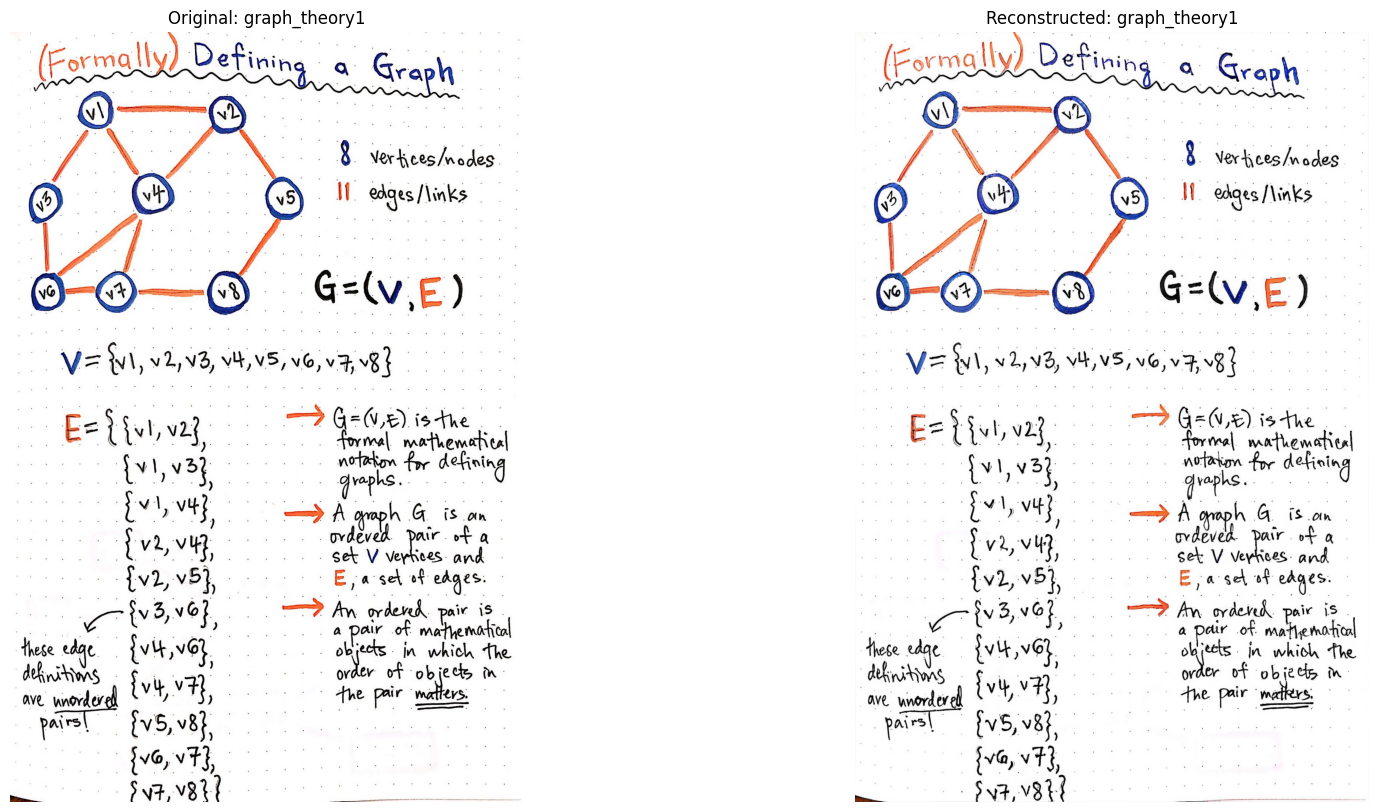

Input image shape: torch.Size([1, 3, 626, 712])
Encoded codes shape: torch.Size([1800])
Number of tokens: 1800
Original image pixels: 445712
Compression ratio: 247.62x


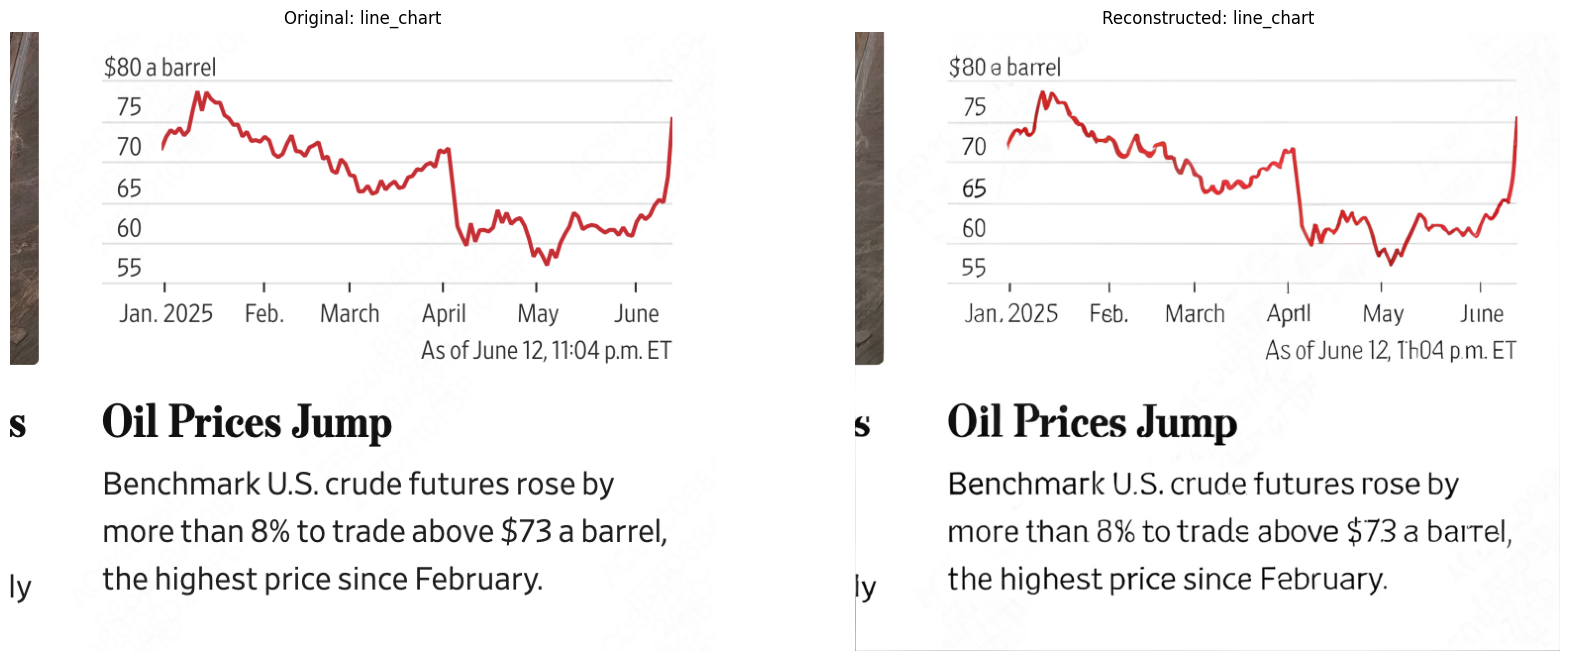

Input image shape: torch.Size([1, 3, 935, 800])
Encoded codes shape: torch.Size([2950])
Number of tokens: 2950
Original image pixels: 748000
Compression ratio: 253.56x


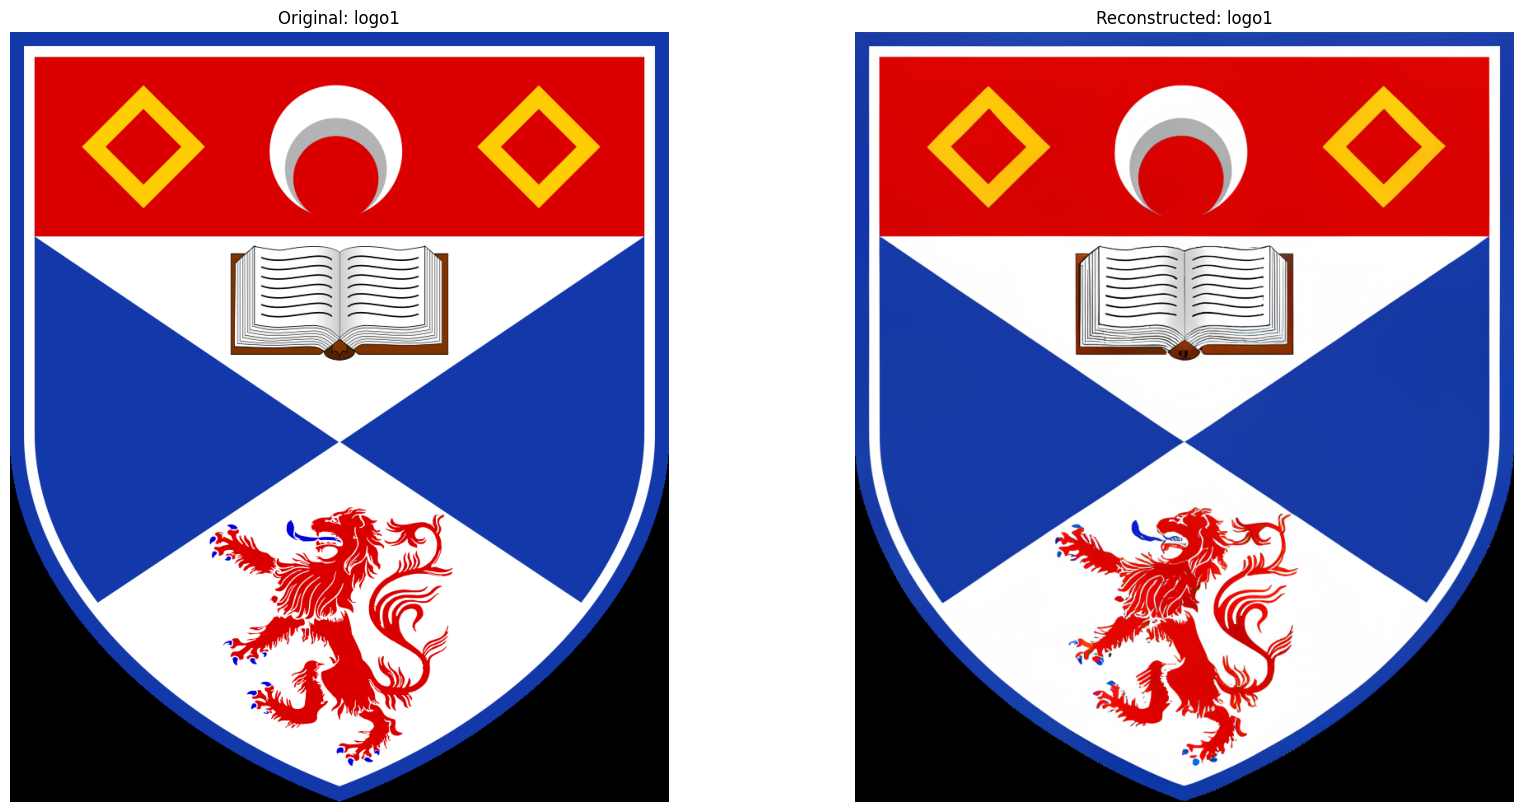

Input image shape: torch.Size([1, 3, 586, 555])
Encoded codes shape: torch.Size([1295])
Number of tokens: 1295
Original image pixels: 325230
Compression ratio: 251.14x


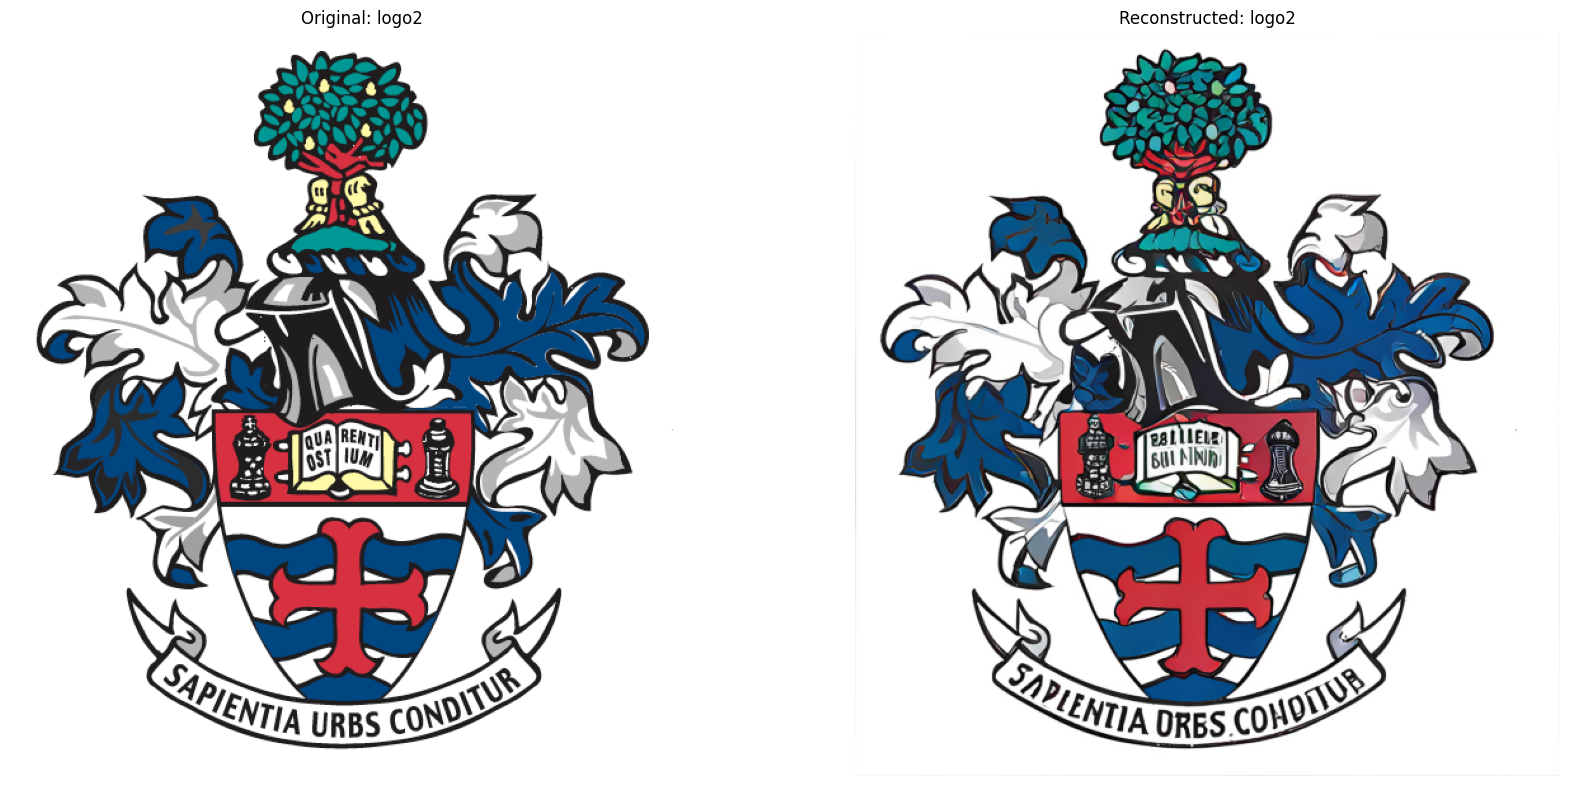

Input image shape: torch.Size([1, 3, 864, 934])
Encoded codes shape: torch.Size([3186])
Number of tokens: 3186
Original image pixels: 806976
Compression ratio: 253.29x


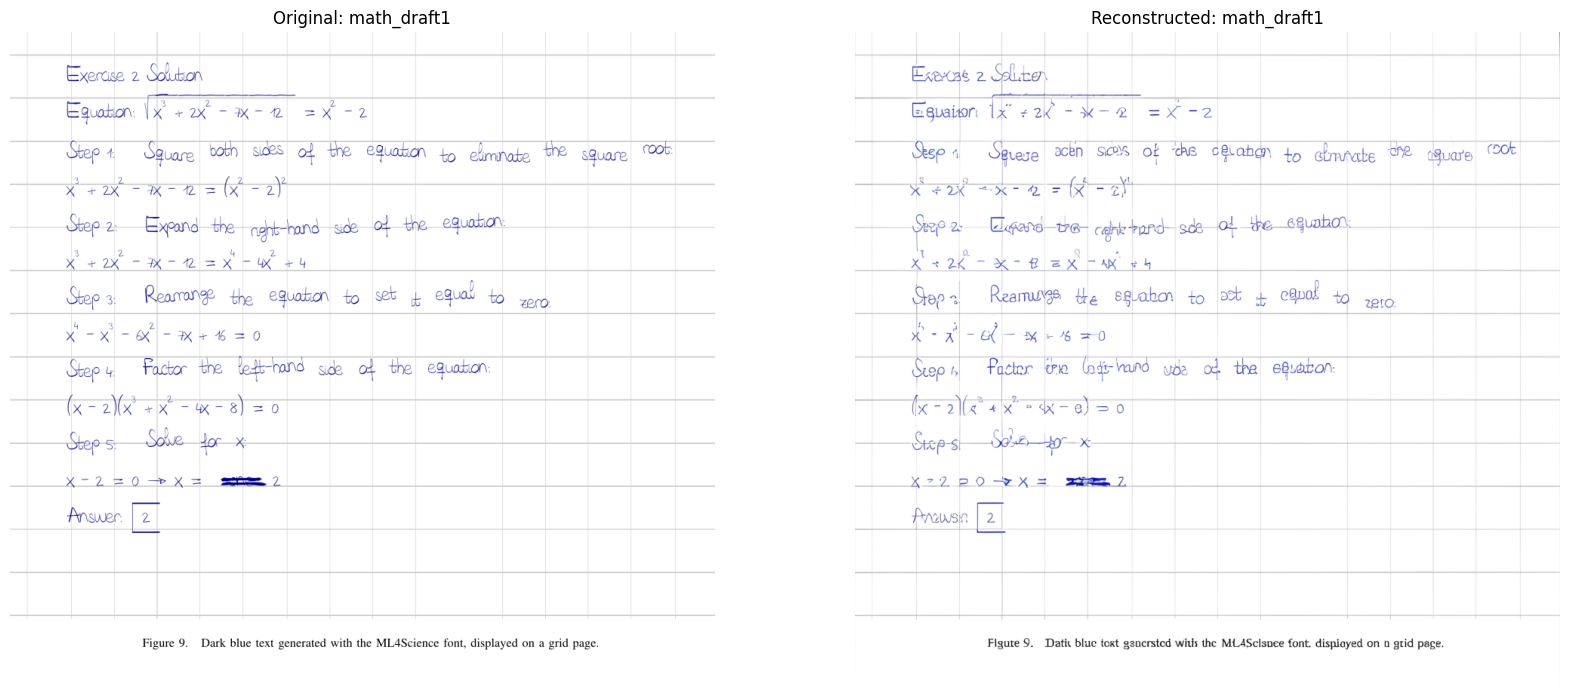

Input image shape: torch.Size([1, 3, 2048, 1536])
Encoded codes shape: torch.Size([12288])
Number of tokens: 12288
Original image pixels: 3145728
Compression ratio: 256.00x


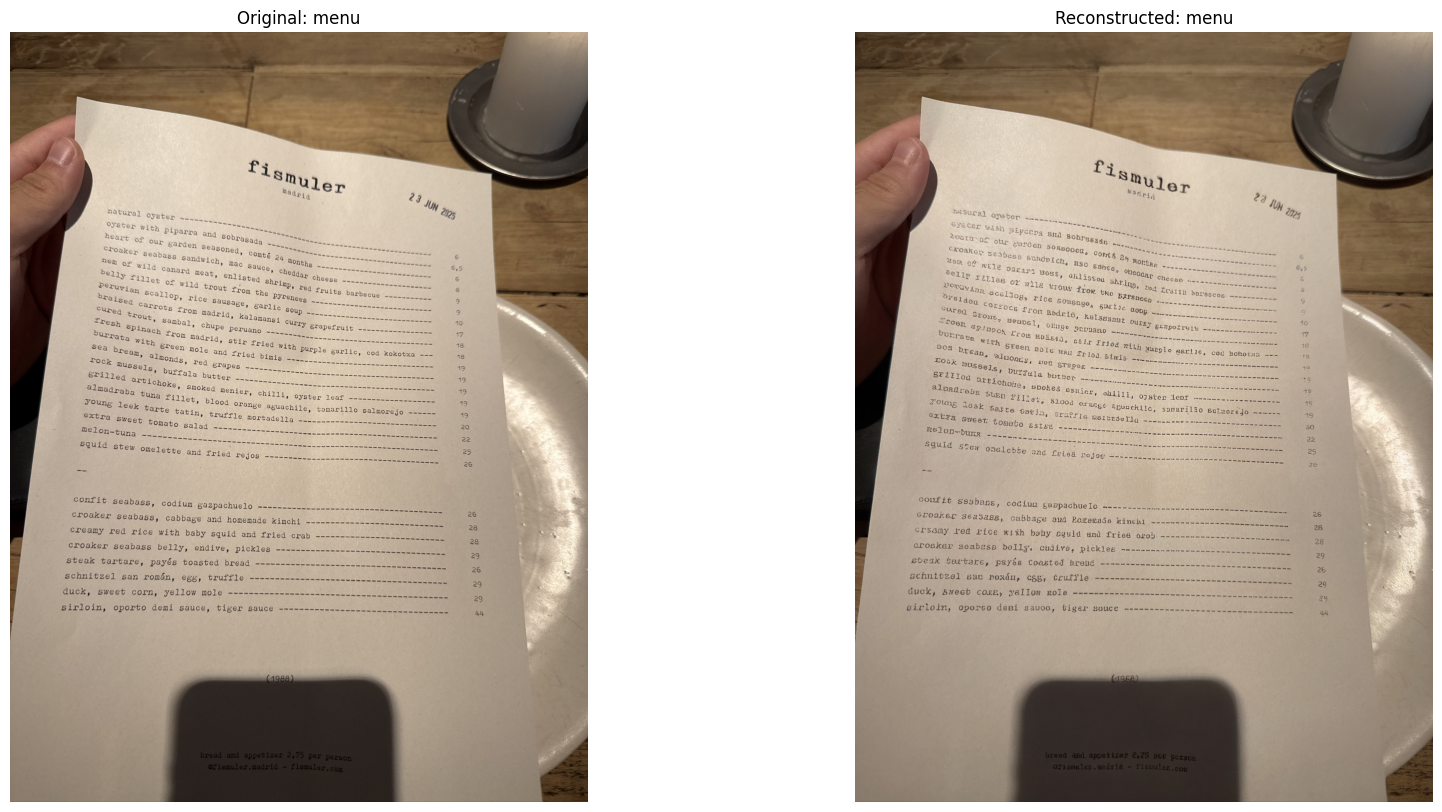

Input image shape: torch.Size([1, 3, 270, 527])
Encoded codes shape: torch.Size([561])
Number of tokens: 561
Original image pixels: 142290
Compression ratio: 253.64x


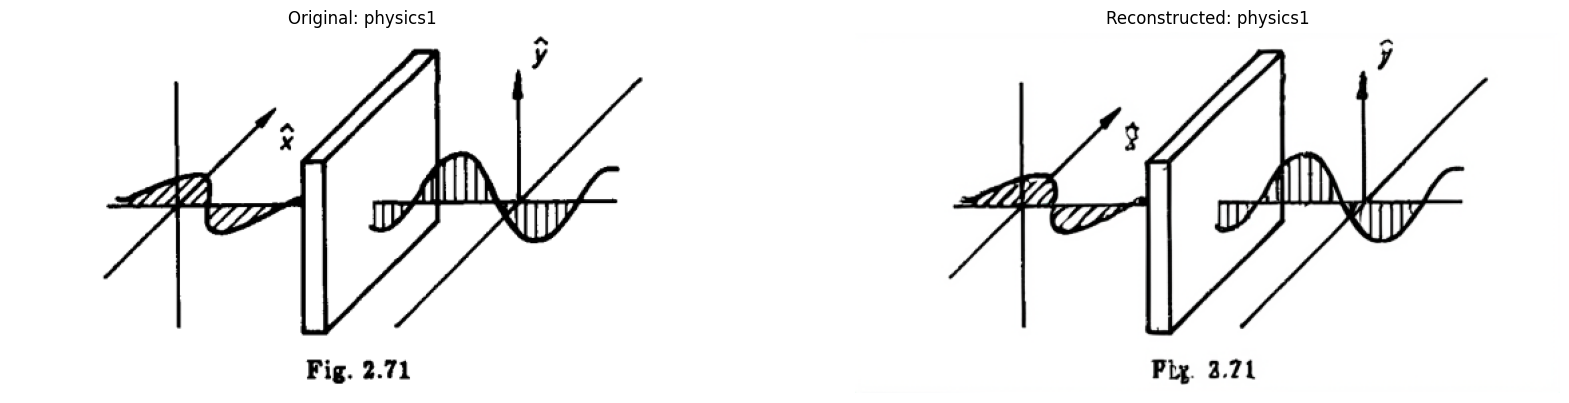

Input image shape: torch.Size([1, 3, 341, 651])
Encoded codes shape: torch.Size([902])
Number of tokens: 902
Original image pixels: 221991
Compression ratio: 246.11x


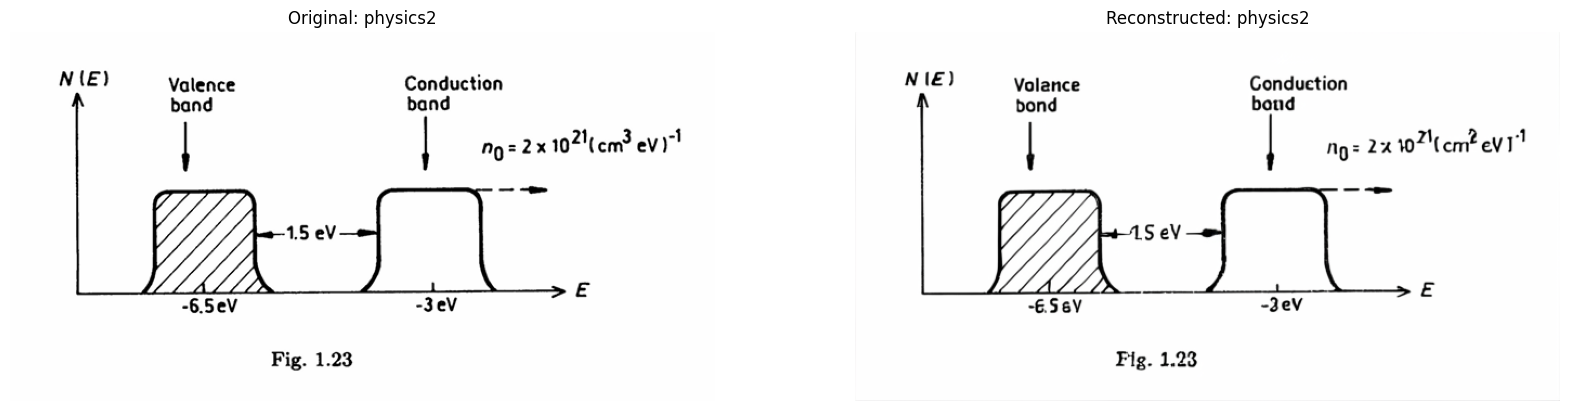

In [22]:
# Process each image
with torch.no_grad():
    for image, name in zip(images, image_names):
        # Convert to tensor (matching the exact preprocessing from ImagePaths)
        if not image.mode == "RGB":
            image = image.convert("RGB")
        
        # Convert to numpy and normalize exactly like in ImagePaths.preprocess_image
        image_np = np.array(image)
        image_np = (image_np/127.5 - 1.0).astype(np.float32)
        
        # Convert to tensor
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        print(f"Input image shape: {image_tensor.shape}")
        
        # Encode/decode (using your exact pipeline)
        images_padded, crop_region = pad_images(image_tensor)
        
        if model.use_ema:
            with model.ema_scope():
                quant, diff, indices, _ = model.encode(images_padded)
                reconstructed = model.decode(quant)
        else:
            quant, diff, indices, _ = model.encode(images_padded)
            reconstructed = model.decode(quant)
        
        print(f"Encoded codes shape: {indices.shape}")
        
        # Calculate tokens and compression ratio
        num_tokens = indices.numel()
        original_pixels = image_tensor.shape[-2] * image_tensor.shape[-1]
        compression_ratio = original_pixels / num_tokens
        
        print(f"Number of tokens: {num_tokens}")
        print(f"Original image pixels: {original_pixels}")
        print(f"Compression ratio: {compression_ratio:.2f}x")
        
        reconstructed = reconstructed.clamp(-1, 1)
        reconstructed = unpad_images(reconstructed, crop_region)
        
        # Show results (ensure tensors are on CPU for custom_to_pil)
        original_pil = custom_to_pil(image_tensor.squeeze(0).cpu())
        reconstructed_pil = custom_to_pil(reconstructed.squeeze(0).cpu())
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        ax1.imshow(original_pil)
        ax1.set_title(f"Original: {name}")
        ax1.axis('off')
        ax2.imshow(reconstructed_pil)
        ax2.set_title(f"Reconstructed: {name}")
        ax2.axis('off')
        plt.show()